In [7]:
import tensorflow as tf
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.cifar10.load_data()

In [8]:
classes=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [9]:
import matplotlib.pyplot as plt

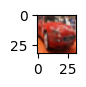

In [12]:
plt.figure(figsize=(0.5,0.5))
plt.imshow(x_train[5])

In [14]:
classes[y_train[3][0]]

'deer'

In [17]:
x_train_scaled=x_train/255
x_test_scaled=x_test/255

In [19]:
y_train_categorical=tf.keras.utils.to_categorical(
    y_train,num_classes=10)
y_train_categorical[:5]
# does one hot encoding on y_train samples

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [21]:
y_test_categorical=tf.keras.utils.to_categorical(
    y_test,num_classes=10)

In [3]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [4]:
model.compile(optimizer='SGD',loss='categorical_crossentropy',metrics=['accuracy'])

In [23]:
model.fit(x_train_scaled,y_train_categorical,epochs=20)

Epoch 1/20
1563/1563 [==============================] - 41s 15ms/step - loss: 1.7622 - accuracy: 0.4020
Epoch 2/20
1563/1563 [==============================] - 23s 15ms/step - loss: 1.2607 - accuracy: 0.5491
Epoch 3/20
1563/1563 [==============================] - 24s 15ms/step - loss: 1.1089 - accuracy: 0.6040
Epoch 4/20
1563/1563 [==============================] - 23s 15ms/step - loss: 1.0040 - accuracy: 0.6417
Epoch 5/20
1563/1563 [==============================] - 24s 15ms/step - loss: 0.9247 - accuracy: 0.6747
Epoch 6/20
1563/1563 [==============================] - 23s 15ms/step - loss: 0.8634 - accuracy: 0.6985
Epoch 7/20
1563/1563 [==============================] - 23s 15ms/step - loss: 0.8264 - accuracy: 0.7099
Epoch 8/20
1563/1563 [==============================] - 25s 16ms/step - loss: 0.7849 - accuracy: 0.7248
Epoch 9/20
1563/1563 [==============================] - 24s 15ms/step - loss: 0.7499 - accuracy: 0.7370
Epoch 10/20
1563/1563 [==============================] - 23s 15m

In [24]:
model.predict(x_test_scaled)

array([[9.1149181e-05, 7.7446294e-04, 4.0333034e-03, ..., 9.3617164e-05,
        5.5360643e-04, 4.7394325e-04],
       [4.6504993e-04, 1.4466292e-03, 4.1384112e-08, ..., 2.6459865e-09,
        9.9807477e-01, 1.3317590e-05],
       [1.1303385e-03, 1.4754186e-03, 3.7474078e-05, ..., 4.1699459e-06,
        9.9707949e-01, 9.9853147e-05],
       ...,
       [1.2141173e-05, 3.8397707e-06, 2.0157064e-03, ..., 2.2116959e-02,
        5.1519910e-05, 4.8349619e-05],
       [7.3350915e-03, 9.7688431e-01, 2.6282428e-03, ..., 1.7717848e-05,
        4.7409948e-04, 2.6727666e-03],
       [1.5120936e-06, 3.3740675e-06, 2.4248151e-05, ..., 9.6966624e-01,
        2.0225559e-06, 4.3013511e-06]], dtype=float32)

In [25]:
model.evaluate(x_test_scaled,y_test_categorical)

313/313 [==============================] - 3s 7ms/step - loss: 0.6780 - accuracy: 0.7758


[0.6780019998550415, 0.7757999897003174]